# Notebook 2: Storage Data~Filtering and Summarising
## Python equivalents of Excel SUMIFS and AVERAGEIFS

This notebook filters and summarises battery storage data using pandas.
We answer targeted questions about storage units based on specific conditions,
replicating what Excel's SUMIFS and AVERAGEIFS functions do, but in Python.

**Dataset:** 25 battery storage units across a 5-bus power grid.

---

## Setup: Load and Prepare Data

Before filtering and summarising, we first load the storage dataset,
merge power capability from Sheet2, and compute energy capacity.

This mirrors the setup in Notebook 1 :  the same clean dataset is the
starting point for all analysis in this notebook.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from both sheets
df1 = pd.read_excel("../data/stordata_sumifs_averageifs.xlsx", 
                     sheet_name="Sheet1", 
                     usecols=[0,1,2,3])

df2 = pd.read_excel("../data/stordata_sumifs_averageifs.xlsx", 
                     sheet_name="Sheet2", 
                     usecols=[1,2])

df2.set_index("id", inplace=True)
df1["power capability"] = df1["id"].map(df2["power capability"])
df1["energy capacity (kWh)"] = df1["power capability"] * df1["duration"]

# Fix bus naming
df1["bus"] = df1["bus"].str.replace("bus 2", "bus_2")

df1.head()

,id,bus,Efficiency,duration,power capability,energy capacity (kWh)
0,stor1,bus_3,0.76,4.0,8,32.0
1,stor2,bus_3,0.87,1.0,5,5.0
2,stor3,bus_3,0.85,0.5,18,9.0
3,stor4,bus_2,0.89,4.0,12,48.0
4,stor5,bus_2,0.87,3.0,5,15.0


---

## Filtering and Summarising Data
### Python equivalents of Excel SUMIFS and AVERAGEIFS

In Excel, SUMIFS and AVERAGEIFS let you calculate totals and averages 
based on one or more conditions. In Python, pandas achieves the same 
result using **boolean filtering** : selecting only rows that meet 
specific criteria before calculating.

---

### Question 1 : What is the total energy capacity of storage units with efficiency above 0.85?

**Excel equivalent:**
`=SUMIFS(energy_capacity, efficiency, ">0.85")`

In [17]:
# Filter rows where efficiency is above 0.85
high_efficiency = df1[df1["Efficiency"] > 0.85]
high_efficiency


,id,bus,Efficiency,duration,power capability,energy capacity (kWh)
1,stor2,bus_3,0.87,1.0,5,5.0
3,stor4,bus_2,0.89,4.0,12,48.0
4,stor5,bus_2,0.87,3.0,5,15.0
7,stor8,bus_1,0.90,1.0,3,3.0
8,stor9,bus_1,0.88,0.5,22,11.0
11,stor12,bus_5,0.92,0.5,99,49.5
12,stor13,bus_5,0.91,1.5,49,73.5
13,stor14,bus_5,0.90,1.0,46,46.0
16,stor17,bus_4,0.90,3.5,33,115.5


In [18]:
# Sum their energy capacity
total = high_efficiency["energy capacity (kWh)"].sum()

print(f"Total energy capacity of units with efficiency > 0.85: {total} kWh")
print(f"Number of units meeting this condition: {len(high_efficiency)}")

Total energy capacity of units with efficiency > 0.85: 366.5 kWh
Number of units meeting this condition: 9


<span style="color:orange;">**Analysis of Question 1 Finding:**</span>

- 9 out of 25 storage units have an efficiency above 0.85.

- 9 out of 25 storage units have an efficiency above 0.85.
- Together these storage units hold a total energy capacity of 366.5 kWh.
- This means the majority of storage units (16 out of 25) operate 
  below the 0.85 efficiency threshold, suggesting room for improvement across the grid.

---

### Question 2: What is the average efficiency of storage units with duration greater than 2 hours?

**Excel equivalent:**
`=AVERAGEIFS(efficiency, duration, ">2")`

In [19]:
# Filter storage units with duration greater than 2 hours
long_duration = df1[df1["duration"] > 2]
long_duration

,id,bus,Efficiency,duration,power capability,energy capacity (kWh)
0,stor1,bus_3,0.76,4.0,8,32.0
3,stor4,bus_2,0.89,4.0,12,48.0
4,stor5,bus_2,0.87,3.0,5,15.0
9,stor10,bus_2,0.65,4.0,2,8.0
10,stor11,bus_5,0.85,6.0,86,516.0
14,stor15,bus_2,0.85,4.0,12,48.0
15,stor16,bus_2,0.77,4.0,25,100.0
16,stor17,bus_4,0.90,3.5,33,115.5
18,stor19,bus_5,0.65,4.0,45,180.0
19,stor20,bus_1,0.81,4.0,76,304.0


In [20]:
# Calculate average efficiency of filtered storage units
avg_eff = long_duration["Efficiency"].mean()

print(f"Average efficiency of storage units with duration > 2 hours: {avg_eff:.2f}")
print(f"Number of storage units meeting this condition: {len(long_duration)}")

Average efficiency of storage units with duration > 2 hours: 0.80
Number of storage units meeting this condition: 13


<span style="color:orange;">**Analysis of Question 2 Finding:**</span>

- 13 out of 25 storage units have a duration greater than 2 hours.
- The average efficiency of these longer duration storage units is 0.80.
- Notably, stor10 and stor19 both have a low efficiency of 0.65, which 
  pulls the average down considerably.
- This suggests that longer duration storage units are not necessarily 
  more efficient; duration and efficiency appear to be independent 
  characteristics in this dataset.

---

### Question 3: Which storage units meet both conditions; efficiency above 0.85 AND duration greater than 2 hours?

**Excel equivalent:**
`=SUMIFS(energy_capacity, efficiency, ">0.85", duration, ">2")`

In [21]:
# Filter storage units meeting both conditions
both_conditions = df1[(df1["Efficiency"] > 0.85) & (df1["duration"] > 2)]

both_conditions[["id", "bus", "Efficiency", "duration", "energy capacity (kWh)"]]

,id,bus,Efficiency,duration,energy capacity (kWh)
3,stor4,bus_2,0.89,4.0,48.0
4,stor5,bus_2,0.87,3.0,15.0
16,stor17,bus_4,0.90,3.5,115.5


<span style="color:orange;">**Analysis of Question 3 Finding:**</span>

- Only 3 out of 25 storage units satisfy both conditions; 
  efficiency above 0.85 AND duration greater than 2 hours.
- stor17 on bus_4 stands out with the highest efficiency (0.90) 
  and the highest energy capacity (115.5 kWh) in this group.
- All 3 storage units are on bus_2 or bus_4, suggesting these 
  buses host the better performing longer duration storage units.
- The small number of storage units meeting both conditions highlights 
  a trade-off in this dataset; high efficiency and long duration 
  do not often occur together.

---


### Question 4: What is the total energy capacity per bus, only counting storage units with efficiency above 0.85?

**Excel equivalent:**
`=SUMIFS(energy_capacity, bus, "bus_1", efficiency, ">0.85")`

In [23]:
# Filter storage units with efficiency above 0.85
high_eff = df1[df1["Efficiency"] > 0.85]

# Group by bus and summarise
result = high_eff.groupby("bus").agg(
    total_capacity=("energy capacity (kWh)", "sum"),
    number_of_units=("id", "count")
).reset_index()

result.columns = ["Bus", "Total Energy Capacity (kWh)", "Number of Storage Units"]
result

,Bus,Total Energy Capacity (kWh),Number of Storage Units
0,bus_1,14.0,2
1,bus_2,63.0,2
2,bus_3,5.0,1
3,bus_4,115.5,1
4,bus_5,169.0,3


<span style="color:orange;">**Analysis of Question 4 Finding:**</span>

- When filtering only high efficiency storage units (above 0.85), 
  bus_5 leads with the highest total energy capacity at 169.0 kWh 
  across 3 storage units.
- This is a significant contrast to Notebook 1 where bus_1 dominated 
  total capacity. When efficiency is factored in as a condition, 
  bus_1 drops to the lowest total capacity at just 14.0 kWh.
- bus_4 has only 1 high efficiency storage unit (stor17) yet contributes 
  115.5 kWh; making it the most impactful single storage unit in this 
  filtered group.
- This shows how applying conditions changes the picture completely; 
  raw totals and conditional totals tell very different stories.


---

### Question 5: Which storage units have both low efficiency and high capacity?

This question identifies underperforming storage units that are carrying 
a large energy load despite low efficiency. In a real grid, these units 
would be priority candidates for replacement or optimisation.

**Conditions used:**
- Low efficiency : below 0.80
- High capacity : above 100 kWh

In [24]:
# Filter storage units with low efficiency AND high capacity
low_eff_high_cap = df1[
    (df1["Efficiency"] < 0.80) & 
    (df1["energy capacity (kWh)"] > 100)
]

low_eff_high_cap[["id", "bus", "Efficiency", "duration", 
                   "power capability", "energy capacity (kWh)"]]

,id,bus,Efficiency,duration,power capability,energy capacity (kWh)
18,stor19,bus_5,0.65,4.0,45,180.0
23,stor24,bus_3,0.75,9.0,52,468.0


<span style="color:orange;">**Analysis of Question 5 Finding:**</span>

- Only 2 storage units have both low efficiency and high capacity.
- stor24 on bus_3 is the most concerning; it has the lowest efficiency in this group (0.75) yet carries the highest energy capacity at 468.0 kWh.This is largely due to its exceptionally long duration of 9 hours.
- This means every time the grid operator charges and discharges stor24 through a full cycle, 25% of that energy is wasted. That's 117 kWh lost per cycle , enough to power several homes for a day.
Now multiply that by 365 days a year. The energy waste is enormous.

- stor19 on bus_5 has an efficiency of 0.65; the lowest in the entire 
  dataset, yet holds 180.0 kWh of capacity.
- In a real grid these two storage units would be priority candidates 
  for efficiency improvement or replacement; they carry significant 
  energy load but perform poorly in terms of efficiency.

---


### Question 6: What are the most common efficiency and duration values across the dataset?

This question examines whether storage units cluster around particular 
efficiency and duration values; revealing patterns in how the grid 
was designed or procured.

In [25]:
# Most common duration values
print("Duration value counts:")
print(df1["duration"].value_counts().head(5))

print()

# Most common efficiency values  
print("Efficiency value counts:")
print(df1["Efficiency"].value_counts().head(5))

Duration value counts:
duration
4.0    9
1.0    5
0.5    3
1.5    2
3.0    1
Name: count, dtype: int64

Efficiency value counts:
Efficiency
0.85    7
0.90    3
0.65    3
0.87    2
0.76    1
Name: count, dtype: int64


<span style="color:orange;">**Analysis of Question 6 Finding:**</span>

**Duration patterns:**
- 4 hours is by far the most common duration with 9 storage units; 
  suggesting the grid was designed around a 4-hour discharge standard.
- Short duration storage units (0.5 and 1 hour) make up 8 storage units 
  combined; these are likely used for frequency regulation and short 
  term grid balancing rather than bulk energy storage.
- Only 1 storage unit has a 3-hour duration; suggesting this is not 
  a preferred configuration in this grid.

**Efficiency patterns:**
- 0.85 is the most common efficiency value with 7 storage units; 
  suggesting this may be a procurement standard or a common battery 
  technology specification in this grid.
- 3 storage units share the low efficiency value of 0.65; these are 
  likely older units or a different technology type altogether.
- The spread of efficiency values from 0.65 to 0.92 suggests the grid 
  contains a mix of battery technologies procured at different times.

---

## Visualisations

---

### Chart 1 Scatter plot : efficiency vs energy capacity

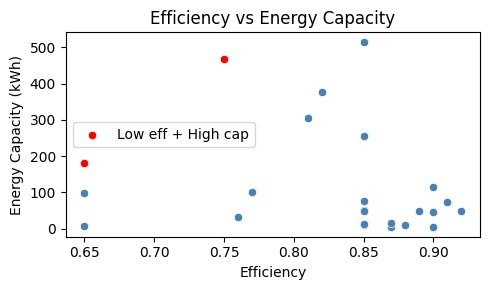

In [26]:
# Scatter plot : efficiency vs energy capacity
plt.figure(figsize=(5, 3))
plt.scatter(df1["Efficiency"], df1["energy capacity (kWh)"], 
            color="steelblue", edgecolors="white", linewidths=0.5)

# Highlight low efficiency high capacity units in red
problem_units = df1[(df1["Efficiency"] < 0.80) & (df1["energy capacity (kWh)"] > 100)]
plt.scatter(problem_units["Efficiency"], problem_units["energy capacity (kWh)"], 
            color="red", edgecolors="white", linewidths=0.5, label="Low eff + High cap")

plt.title("Efficiency vs Energy Capacity")
plt.xlabel("Efficiency")
plt.ylabel("Energy Capacity (kWh)")
plt.legend()
plt.tight_layout()
plt.show()

<span style="color:pink;">*Figure 1 : Each dot represents one storage unit. 
Red dots highlight storage units with low efficiency (below 0.80) 
and high energy capacity (above 100 kWh) ; these are priority 
candidates for optimisation in a real grid.*</span>

---

### Chart 2 : Total Energy Capacity per Bus (High Efficiency Storage Units Only)

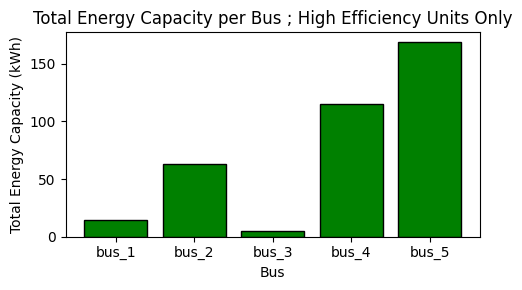

In [28]:
# Bar chart : total capacity per bus for high efficiency storage units only
plt.figure(figsize=(5, 3))
plt.bar(result["Bus"], result["Total Energy Capacity (kWh)"], color="green", edgecolor="black")
plt.title("Total Energy Capacity per Bus ; High Efficiency Units Only")
plt.xlabel("Bus")
plt.ylabel("Total Energy Capacity (kWh)")
plt.tight_layout()
plt.show()

<span style="color:pink;">*Figure 2 : Total energy capacity per bus counting only storage units 
with efficiency above 0.85. Compare with Notebook 1 Figure 1 where bus_1 
dominated ; here bus_5 leads, showing how efficiency filtering 
changes the picture completely.*</span>

---

## Conclusions

This notebook replicated Excel SUMIFS and AVERAGEIFS functionality 
using pandas boolean filtering and groupby aggregation across 6 questions.

**Key findings:**

- Filtering by efficiency above 0.85 revealed only 9 out of 25 storage 
  units meet this threshold; suggesting the majority of the grid operates 
  below modern efficiency standards.

- Only 3 storage units satisfy both high efficiency AND long duration 
  conditions simultaneously; confirming that these two desirable 
  characteristics rarely occur together in this dataset.

- stor24 on bus_3 is the most concerning unit in the grid ; it carries 
  the highest energy capacity at 468 kWh but has a low efficiency of 0.75. 
  At scale, 25% of energy is wasted every charge/discharge cycle.

- stor19 has the lowest efficiency in the entire dataset at 0.65 ; 
  meaning 35% of energy input is lost per cycle.

- 4 hours is the dominant duration value and 0.85 is the dominant 
  efficiency value ; suggesting these represent the design standard 
  for this grid.

- When efficiency is used as a filter, bus_5 becomes the strongest 
  performer ; replacing bus_1 which dominated raw totals in Notebook 1. 
  This highlights how conditional analysis tells a different story 
  from unconditional totals.

**Engineering implication:**
Raw capacity totals alone are misleading. A grid optimisation strategy 
must consider efficiency alongside capacity ; high capacity low efficiency 
storage units represent significant energy waste and should be prioritised 
for replacement or operational optimisation.

## Next Steps
- Notebook 3 : Rebuild all charts as interactive visualisations using Plotly
- Notebook 4 : Cost-effectiveness scoring ; which storage units deliver 
  the best value combining efficiency, capacity and estimated cost